# Data Preparation
**Job Recommendation Insights — Step 1 of 3**

This notebook:
1. Loads the raw Campus Recruitment dataset
2. Performs exploratory data analysis (EDA)
3. Cleans and encodes features
4. Scales numerical columns
5. Splits into train/test sets and saves to `data/`

**Run this notebook FIRST before classification.ipynb or clustering.ipynb.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

os.makedirs('data', exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Dataset

In [2]:
df = pd.read_csv('Placement_Data_Full_Class.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (215, 15)


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.00,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.50,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.00,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.80,Mkt&Fin,55.50,Placed,425000.0
5,6,M,55.00,Others,49.80,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed,NaN
6,7,F,46.00,Others,49.20,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed,NaN
7,8,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.00,Mkt&Fin,62.14,Placed,252000.0
8,9,M,73.00,Central,79.00,Central,Commerce,72.00,Comm&Mgmt,No,91.34,Mkt&Fin,61.29,Placed,231000.0
9,10,M,58.00,Central,70.00,Central,Commerce,61.00,Comm&Mgmt,No,54.00,Mkt&Fin,52.21,Not Placed,NaN


In [3]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Basic Stats ---')
df.describe()

--- Data Types ---
sl_no               int64
gender                str
ssc_p             float64
ssc_b                 str
hsc_p             float64
hsc_b                 str
hsc_s                 str
degree_p          float64
degree_t              str
workex                str
etest_p           float64
specialisation        str
mba_p             float64
status                str
salary            float64
dtype: object

--- Missing Values ---
sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

--- Basic Stats ---


,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


## 2. Exploratory Data Analysis

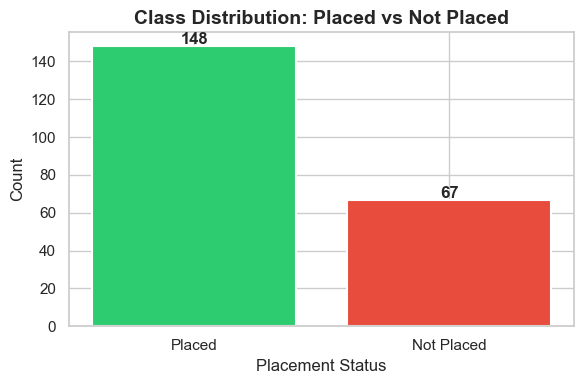

status
Placed        148
Not Placed     67
Name: count, dtype: int64


In [4]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['status'].value_counts()
ax.bar(counts.index, counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
ax.set_title('Class Distribution: Placed vs Not Placed', fontsize=14, fontweight='bold')
ax.set_xlabel('Placement Status')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('data/class_distribution.png', dpi=150)
plt.show()
print(counts)

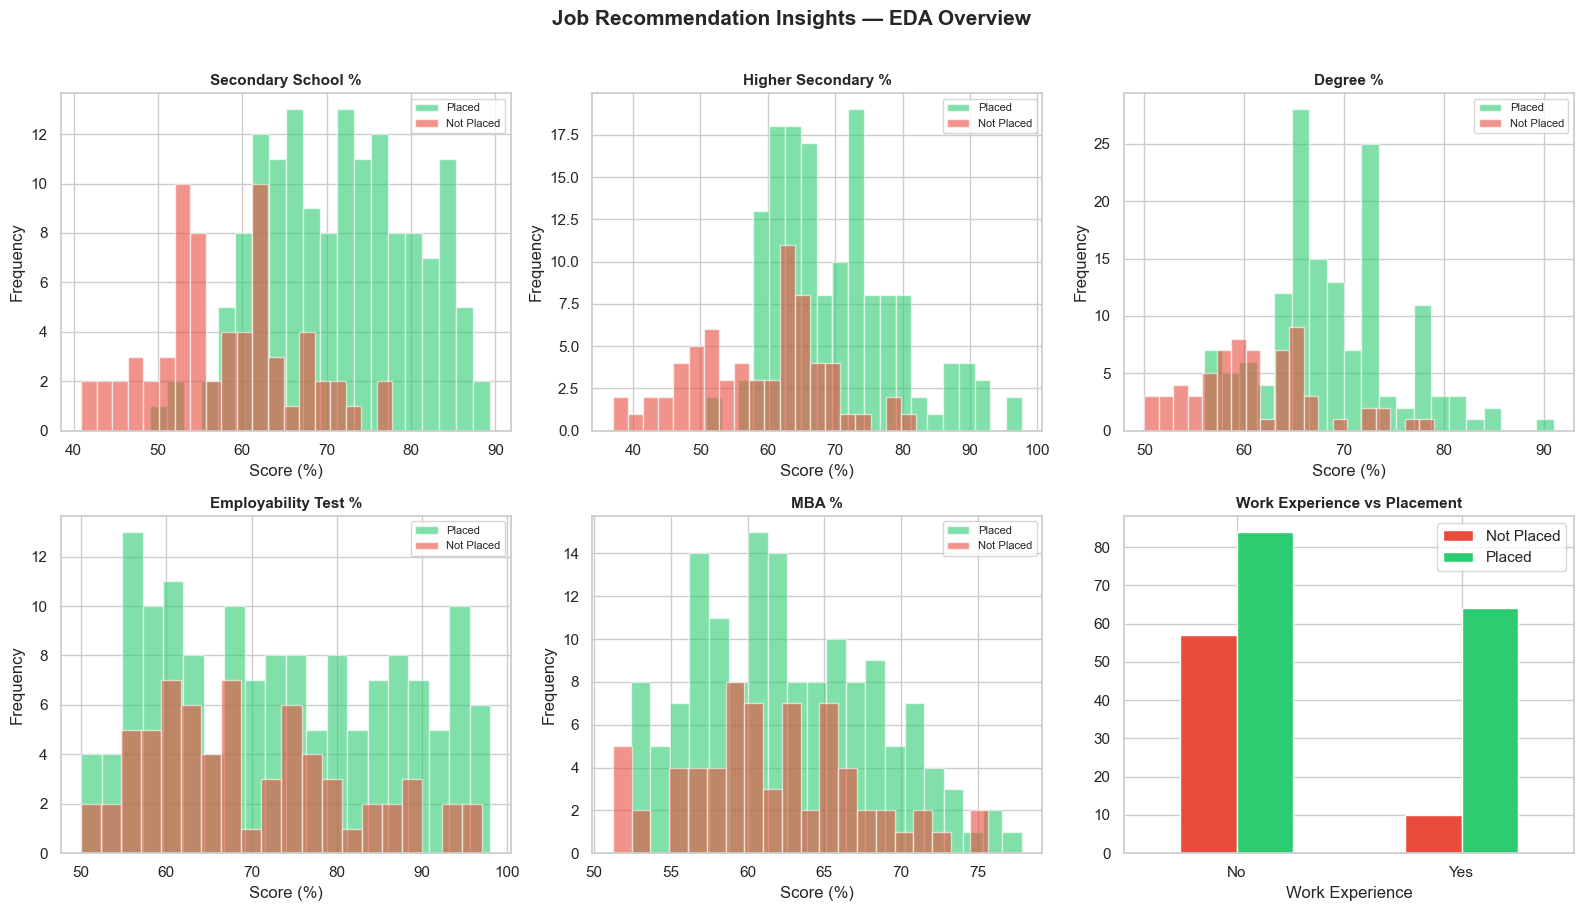

In [5]:
# EDA overview: distributions of numerical features by placement status
num_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

labels = {
    'ssc_p': 'Secondary School %',
    'hsc_p': 'Higher Secondary %',
    'degree_p': 'Degree %',
    'etest_p': 'Employability Test %',
    'mba_p': 'MBA %'
}

for i, col in enumerate(num_cols):
    for status, color in [('Placed', '#2ecc71'), ('Not Placed', '#e74c3c')]:
        subset = df[df['status'] == status][col].dropna()
        axes[i].hist(subset, bins=20, alpha=0.6, label=status, color=color, edgecolor='white')
    axes[i].set_title(labels[col], fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Score (%)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

# Categorical: work experience
workex_placed = df.groupby(['workex', 'status']).size().unstack(fill_value=0)
workex_placed.plot(kind='bar', ax=axes[5], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[5].set_title('Work Experience vs Placement', fontsize=11, fontweight='bold')
axes[5].set_xlabel('Work Experience')
axes[5].set_xticklabels(axes[5].get_xticklabels(), rotation=0)
axes[5].legend(['Not Placed', 'Placed'])

fig.suptitle('Job Recommendation Insights — EDA Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

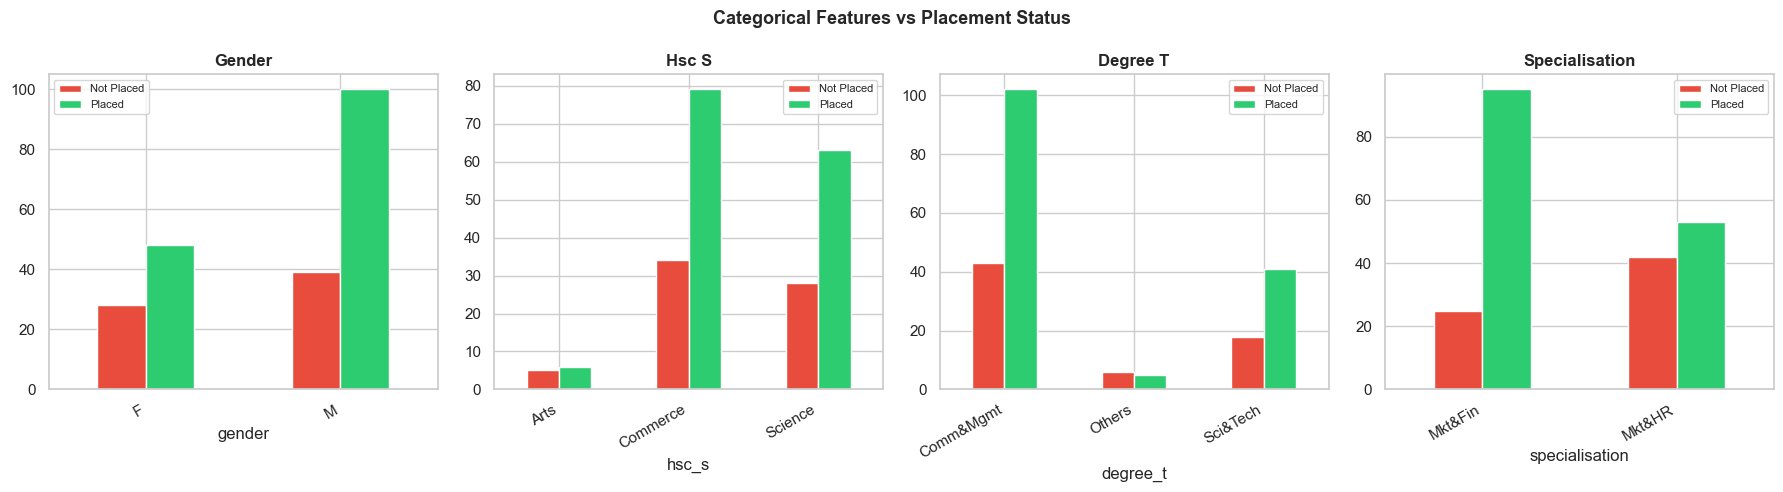

In [6]:
# Categorical feature breakdowns
cat_cols = ['gender', 'hsc_s', 'degree_t', 'specialisation']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, col in zip(axes, cat_cols):
    ct = df.groupby([col, 'status']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'], edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(['Not Placed', 'Placed'], fontsize=8)

plt.suptitle('Categorical Features vs Placement Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/categorical_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Cleaning & Encoding

In [7]:
# Drop 'sl_no' (row ID) and 'salary' (target leakage — only exists for placed students)
df_clean = df.drop(columns=['sl_no', 'salary'])

# Encode target
df_clean['status'] = (df_clean['status'] == 'Placed').astype(int)

# Encode all remaining categorical columns with LabelEncoder
cat_features = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_features}')

le = LabelEncoder()
for col in cat_features:
    df_clean[col] = le.fit_transform(df_clean[col])

print(f'\nEncoded shape: {df_clean.shape}')
df_clean.head()

Categorical columns to encode: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']

Encoded shape: (215, 13)


C:\Users\kusal\AppData\Local\Temp\ipykernel_25584\261745186.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df_clean.select_dtypes(include='object').columns.tolist()


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status
0,1,67.00,1,91.00,1,1,58.00,2,0,55.0,1,58.80,1
1,1,79.33,0,78.33,1,2,77.48,2,1,86.5,0,66.28,1
2,1,65.00,0,68.00,0,0,64.00,0,0,75.0,0,57.80,1
3,1,56.00,0,52.00,0,2,52.00,2,0,66.0,1,59.43,0
4,1,85.80,0,73.60,0,1,73.30,0,0,96.8,0,55.50,1


In [8]:
# Verify no missing values remain
print('Missing values after cleaning:')
print(df_clean.isnull().sum())

Missing values after cleaning:
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
dtype: int64


## 4. Correlation Heatmap

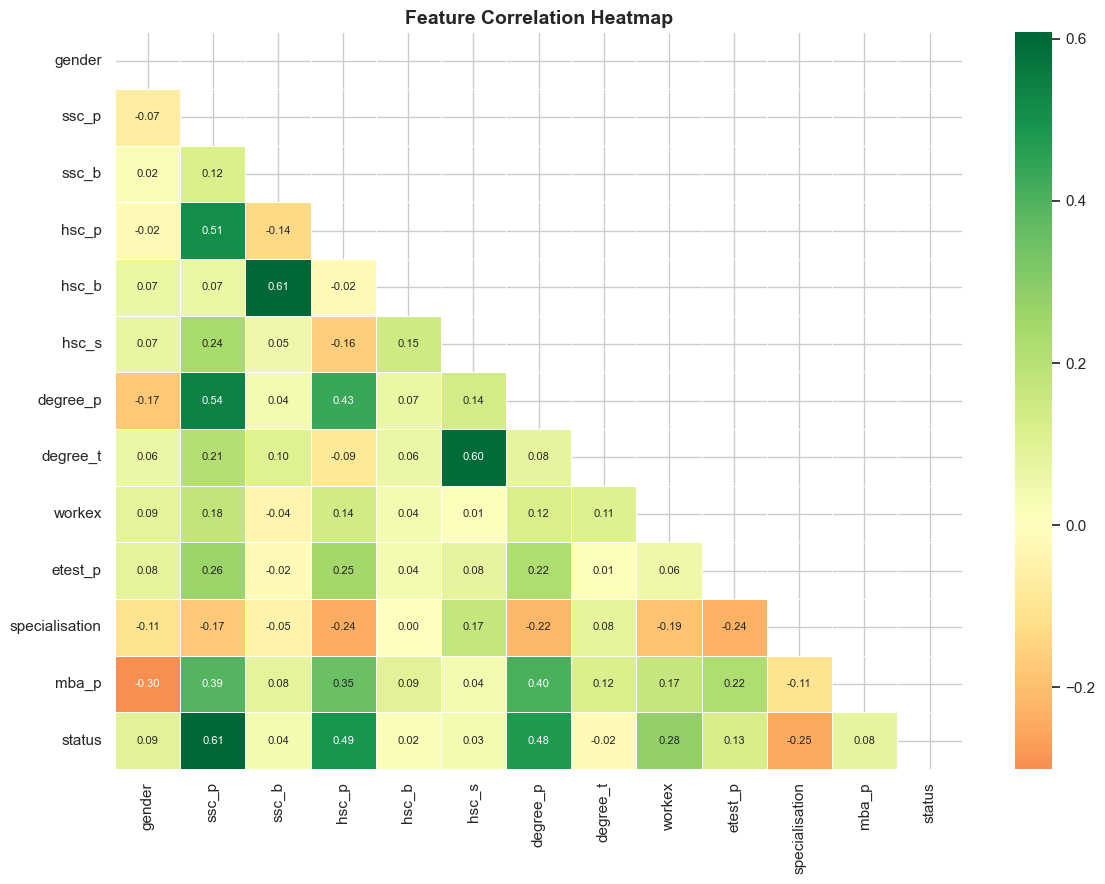

In [9]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Scaling & Train/Test Split

In [10]:
X = df_clean.drop(columns=['status'])
y = df_clean['status']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Also create a scaled version of the full dataset for clustering
X_all_scaled = scaler.transform(X)

print(f'Training set:   {X_train_scaled.shape[0]} samples')
print(f'Test set:       {X_test_scaled.shape[0]} samples')
print(f'Full dataset:   {X_all_scaled.shape[0]} samples')
print(f'Class balance (train): {y_train.value_counts().to_dict()}')

Training set:   172 samples
Test set:       43 samples
Full dataset:   215 samples
Class balance (train): {1: 118, 0: 54}


## 6. Save Processed Data

In [11]:
import joblib

np.save('data/X_train.npy', X_train_scaled)
np.save('data/X_test.npy',  X_test_scaled)
np.save('data/y_train.npy', y_train.values)
np.save('data/y_test.npy',  y_test.values)
np.save('data/X_all_scaled.npy', X_all_scaled)
np.save('data/y_all.npy', y.values)

# Save feature names for later use
pd.Series(X.columns.tolist()).to_csv('data/feature_names.csv', index=False)

print('Saved to data/:')
for f in os.listdir('data'):
    print(f'  {f}')

Saved to data/:
  .ipynb_checkpoints
  categorical_eda.png
  class_distribution.png
  correlation_heatmap.png
  eda_overview.png
  feature_names.csv
  kmeans_elbow.png
  knn_k_selection.png
  pca_ground_truth.png
  X_all_scaled.npy
  X_test.npy
  X_train.npy
  y_all.npy
  y_test.npy
  y_train.npy


---
## Summary

| Step | Action | Result |
|------|--------|--------|
| Load | Read CSV | 215 rows × 14 columns |
| Drop | sl_no, salary | Removes ID + leakage column |
| Encode | LabelEncoder on categoricals | All features now numeric |
| Scale | StandardScaler | Zero mean, unit variance |
| Split | 80/20 stratified | 172 train / 43 test |
| Save | .npy arrays | Ready for classification & clustering |

**→ Next: Run `classification.ipynb`**